In [2]:
import yfinance as yf
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


In [3]:
# -------------------------------
# 1. LOAD DATA
# -------------------------------
data = yf.download("RELIANCE.NS", start="2018-01-01")

[*********************100%***********************]  1 of 1 completed


In [4]:
# -------------------------------
# 2. FEATURE ENGINEERING
# -------------------------------

# Moving Averages (trend)
data['MA_10'] = data['Close'].rolling(window=10).mean()
data['MA_50'] = data['Close'].rolling(window=50).mean()

# RSI (momentum)
delta = data['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
data['RSI'] = 100 - (100 / (1 + rs))

# MACD (trend + momentum)
data['EMA_12'] = data['Close'].ewm(span=12, adjust=False).mean()
data['EMA_26'] = data['Close'].ewm(span=26, adjust=False).mean()
data['MACD'] = data['EMA_12'] - data['EMA_26']
data['Signal'] = data['MACD'].ewm(span=9, adjust=False).mean()

# Remove NaN rows
data = data.dropna()

# -------------------------------
# 3. CREATE TARGET
# -------------------------------
# 1 = price goes up tomorrow, 0 = goes down
data['Target'] = (data['Close'].shift(-1) > data['Close']).astype(int)
data = data[:-1]  # remove last row

# -------------------------------
# 4. SELECT FEATURES
# -------------------------------
features = ['MA_10', 'MA_50', 'RSI', 'MACD', 'Signal']
X = data[features]
y = data['Target']

# -------------------------------
# 5. TRAIN-TEST SPLIT
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# -------------------------------
# 6. TRAIN MODEL
# -------------------------------
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# -------------------------------
# 7. PREDICTION
# -------------------------------
y_pred = model.predict(X_test)

# -------------------------------
# 8. EVALUATION
# -------------------------------
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.4987405541561713
              precision    recall  f1-score   support

           0       0.50      0.45      0.47       198
           1       0.50      0.54      0.52       199

    accuracy                           0.50       397
   macro avg       0.50      0.50      0.50       397
weighted avg       0.50      0.50      0.50       397



RSI       0.210937
Signal    0.205970
MACD      0.200371
MA_10     0.191453
MA_50     0.191268
dtype: float64
Filtered Accuracy: 0.5238095238095238


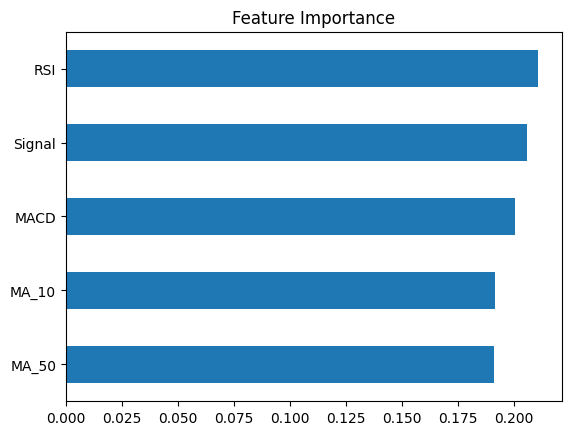

In [5]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=features)
print(importance.sort_values(ascending=False))

importance.sort_values().plot(kind='barh', title='Feature Importance')
probs = model.predict_proba(X_test)

confidence = probs.max(axis=1)

# Only take predictions with >60% confidence
high_conf = confidence > 0.6

filtered_accuracy = accuracy_score(y_test[high_conf], y_pred[high_conf])

print("Filtered Accuracy:", filtered_accuracy)


In [6]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Scale data (important for neural networks)
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data[['Close']])

# Create sequences (last 60 days → predict next day)
X_lstm = []
y_lstm = []

for i in range(60, len(scaled_data)):
    X_lstm.append(scaled_data[i-60:i])
    y_lstm.append(scaled_data[i])

X_lstm = np.array(X_lstm)
y_lstm = np.array(y_lstm)

print("X shape:", X_lstm.shape)
print("y shape:", y_lstm.shape)

X shape: (1924, 60, 1)
y shape: (1924, 1)


In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Build model
model = Sequential()

# LSTM layer (important)
model.add(LSTM(units=50, return_sequences=False, input_shape=(60, 1)))

# Output layer
model.add(Dense(1))

# Compile model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train model
model.fit(X_lstm, y_lstm, epochs=5, batch_size=32)

Epoch 1/5


/Users/meetpatil/Desktop/stock-ai-project/.venv/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0673
Epoch 2/5
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0019
Epoch 3/5
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0010
Epoch 4/5
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 9.8080e-04
Epoch 5/5
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 9.1894e-04


In [8]:
predictions = model.predict(X_lstm)

print(predictions[:5])

61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
[[0.04986484]
 [0.05147856]
 [0.05340229]
 [0.05547051]
 [0.05762119]]


In [9]:
# -------------------------------
# STEP 1: Convert predictions back
# -------------------------------
predicted_prices = scaler.inverse_transform(predictions)
actual_prices = scaler.inverse_transform(y_lstm)

# -------------------------------
# STEP 2: Generate signals (IMPROVED)
# -------------------------------
threshold = 0.02  # 2% movement
signals = []

for i in range(1, len(predicted_prices)):
    
    change = (predicted_prices[i][0] - actual_prices[i-1][0]) / actual_prices[i-1][0]
    
    if change > threshold:
        signals.append("BUY")
    elif change < -threshold:
        signals.append("SELL")
    else:
        signals.append("HOLD")

print("Sample Signals:", signals[:10])

# -------------------------------
# STEP 3: BACKTESTING (REALISTIC)
# -------------------------------
initial_money = 100000  # ₹1 lakh
money = initial_money
position = 0  # number of shares
fee = 0.001  # 0.1% transaction cost

for i in range(len(signals)):
    
    price = actual_prices[i][0]
    
    # BUY
    if signals[i] == "BUY" and money > 0:
        position = (money * (1 - fee)) / price
        money = 0
    
    # SELL
    elif signals[i] == "SELL" and position > 0:
        money = position * price * (1 - fee)
        position = 0

# -------------------------------
# STEP 4: FINAL VALUE
# -------------------------------
if position > 0:
    final_value = position * actual_prices[-1][0]
else:
    final_value = money

# -------------------------------
# STEP 5: RESULTS
# -------------------------------
print("\n===== BACKTEST RESULTS =====")
print("Initial Money:", initial_money)
print("Final Money:", round(final_value, 2))
print("Profit:", round(final_value - initial_money, 2))
print("Return %:", round(((final_value - initial_money) / initial_money) * 100, 2), "%")

Sample Signals: ['BUY', 'BUY', 'BUY', 'BUY', 'BUY', 'BUY', 'BUY', 'BUY', 'BUY', 'BUY']

===== BACKTEST RESULTS =====
Initial Money: 100000
Final Money: 143691.4
Profit: 43691.4
Return %: 43.69 %


In [10]:
model.save("lstm_model.h5")